In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
%matplotlib inline
import matplotlib.pyplot as plt
import sys # sys.path

In [5]:
df_ECS_comparison= pd.read_csv('Documents/Masters Thesis CSV/ECS_last_row_4x(in).csv')
df_ECS_comparison

,Unnamed: 0,Model,TCR_G,ECS_G,TCR_GCM,ECS_GCM
0,1,AWI-CM-1-1-MR,2.229827,3.127919,NaN,3.124480
1,2,BCC-CSM2-MR,1.906368,3.023289,NaN,3.021214
2,3,BCC-ESM1,2.097153,3.337577,NaN,3.343795
3,4,CAMS-CSM1-0,1.771039,2.300185,NaN,2.318158
4,5,FGOALS-f3-L,2.111575,2.997232,NaN,3.009530
5,6,CanESM5,3.180986,5.657833,NaN,5.615460
6,7,ACCESS-CM2,2.693252,4.697275,NaN,4.727742
7,8,E3SM-1-0,3.140480,5.312092,NaN,5.329391
8,9,INM-CM4-8,1.303369,1.830486,NaN,1.844137
9,10,INM-CM5-0,1.449437,1.914223,NaN,1.901515


In [7]:
df_ECS_comparison['Model ']

0     AWI-CM-1-1-MR
1       BCC-CSM2-MR
2          BCC-ESM1
3       CAMS-CSM1-0
4       FGOALS-f3-L
5           CanESM5
6        ACCESS-CM2
7          E3SM-1-0
8         INM-CM4-8
9         INM-CM5-0
10     IPSL-CM6A-LR
11           MIROC6
12    MPI-ESM1-2-HR
13       MRI-ESM2-0
14      GISS-E2-1-G
15      GISS-E2-1-H
16      GISS-E2-2-G
17      CESM2-WACCM
18            CESM2
19        GFDL-ESM4
20            NESM3
21      SAM0-UNICON
Name: Model , dtype: object

In [9]:
print(df_ECS_comparison.columns)

Index(['Unnamed: 0', 'Model ', 'TCR_G', 'ECS_G', 'TCR_GCM', 'ECS_GCM'], dtype='object')


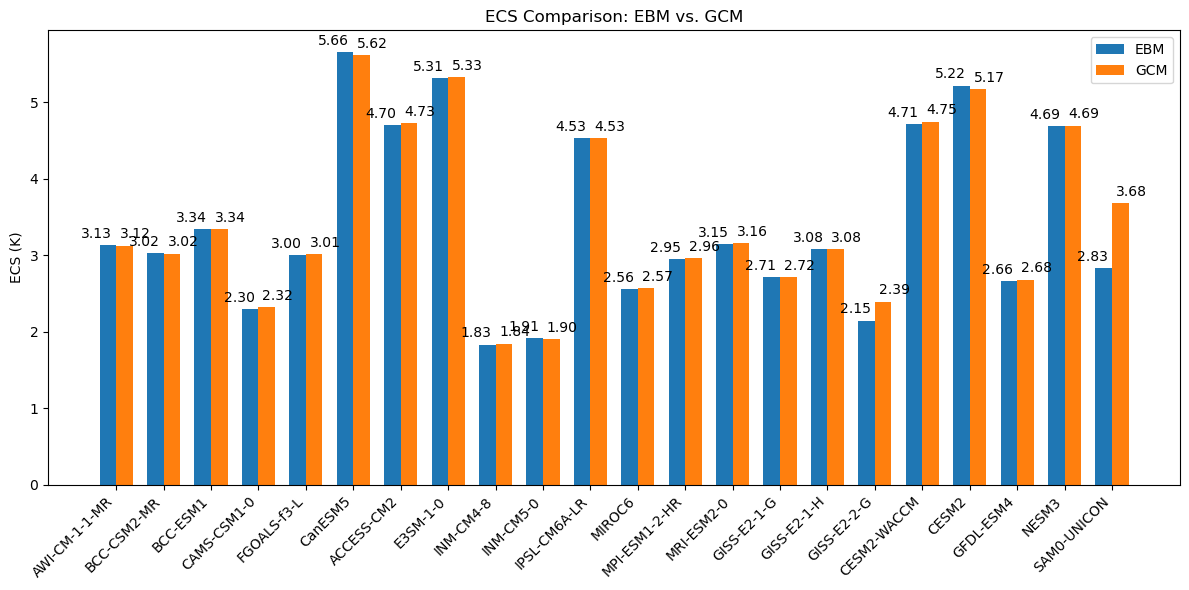

In [13]:
# Assuming df_ECS_comparison is already read and cleaned:
df_ECS_comparison.columns = df_ECS_comparison.columns.str.strip()
model_names = df_ECS_comparison['Model']
ecs_g = df_ECS_comparison['ECS_G']
ecs_gcm = df_ECS_comparison['ECS_GCM']

# Create an index for each model
x = np.arange(len(model_names))
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, ecs_g, width, label='EBM')
rects2 = ax.bar(x + width/2, ecs_gcm, width, label='GCM')

ax.set_ylabel('ECS (K)')
ax.set_title('ECS Comparison: EBM vs. GCM')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()

# Function to annotate bars with an adjustable horizontal offset.
def autolabel(rects, offset=0):
    """
    Attach a text label above each bar displaying its height.
    offset: horizontal offset for the label
    """
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(offset, 3),  # horizontal offset in points, vertical offset fixed at 3
                    textcoords="offset points",
                    ha='center', va='bottom')

# Apply different offsets for each group to avoid overlap.
autolabel(rects1, offset=-8)
autolabel(rects2, offset=8)

plt.tight_layout()
plt.savefig('ECS_comparsion_(EBM)vs(GCM)', dpi = 600)
plt.show()